# Capstone 2: Business Analysis with Python
## EmporiUm Sales Territory Analysis 

**Analyst:** Jonathan Lopez
**Program:** Year Up United - Data Analytics
**Date:** 2025

---

### Territories Analyzed 
Territory 1: Connecticut  |  East Region  | Manager: Ellen Lemon

Territory 2: New York   | East Region  | Manager: See Ellefson

This notebook walks through a full analysis of EmporiUm store sales data for the Connecticut and New York territories. The analysis covers monthly revenue trends, store peformance rankings, top customers, and product category breakdowns. Along with a final recommendation for marketing focus in the next quarter.

In [1]:
# Libraries i'll be using during this analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Step 1 - Load and Inspect Data Files

In [2]:
# Load the customer list
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.info()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [3]:
# Load product categories
product_cats = pd.read_csv('ProductCategories.csv')
product_cats.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [4]:
# Load products
products = pd.read_csv('Products.csv')
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [5]:
# Store detail
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [6]:
# Store Sales
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


## Core Marketing Analysis

The following sections below this cell is to address each question for the managers. It will be data filtered to the Connecticut and New York territories and analyzed step by step.

## Setup - Identifying Store IDs and Parse dates for the territories

In [7]:
# Parse Transaction date to datetime and add YearMonth column
store_sales['Transaction Date'] = pd.to_datetime(
    store_sales['Transaction Date'], format='%m/%d/%Y'
)
store_sales['YearMonth'] = store_sales['Transaction Date'].dt.to_period('M')

# Get the store IDs for each territory
ct_ids = store_detail[store_detail['State'] == 'Connecticut']['Store ID'].tolist()
ny_ids = store_detail[store_detail['State'] == 'New York']['Store ID'].tolist()

# Filter the sales to each territory
ct_sales = store_sales[store_sales['Store ID'].isin(ct_ids)].copy()
ny_sales = store_sales[store_sales['Store ID'].isin(ny_ids)].copy()

print(f"Connecticut Store IDs: {ct_ids}")
print(f"New York Store IDs: {ny_ids}")
print(f"\nCT Transactions:  {len(ct_sales):,}")
print(f"NY Transactions:  {len(ny_sales):,}")

Connecticut Store IDs: [865, 866, 867, 868, 869, 870, 871, 872]
New York Store IDs: [840, 841, 842, 843, 844, 845, 846, 847, 848, 849, 850, 851]

CT Transactions:  17,378
NY Transactions:  31,039


---
### Question 1: Territory Managers, Store IDs, and Cities

**Who are the territory managers for the assigned sales territories?**

**What are the store IDs and cities for the stores in each territroy?**

In [8]:
my_territories = store_detail[store_detail['State'].isin(['Connecticut', 'New York'])][
['Store Location', 'State', 'Store ID', 'Territory Manager']
].reset_index(drop=True)

print("Assigned Sales Territories")
print("=" * 55)
print(my_territories.to_string(index=False))

Assigned Sales Territories
   Store Location       State  Store ID Territory Manager
       Bridgeport Connecticut       865       Ellen Lemon
           Darien Connecticut       866       Ellen Lemon
         Hartford Connecticut       867       Ellen Lemon
Litchfield County Connecticut       868       Ellen Lemon
        New Haven Connecticut       869       Ellen Lemon
       New London Connecticut       870       Ellen Lemon
     Old Saybrook Connecticut       871       Ellen Lemon
        Waterbury Connecticut       872       Ellen Lemon
           Albany    New York       840      See Ellefson
          Buffalo    New York       841      See Ellefson
           Elmira    New York       842      See Ellefson
           Ithaca    New York       843      See Ellefson
           Oswego    New York       844      See Ellefson
      Plattsburgh    New York       845      See Ellefson
      Poestenkill    New York       846      See Ellefson
        Rochester    New York       847      

---
### Question 2: Monthly Total Revenue by Territory

**What is the monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the date?**

In [9]:
# Group sales by month
ct_monthly = ct_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()
ct_monthly.columns = ['Month', 'CT Revenue']

ny_monthly = ny_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()
ny_monthly.columns = ['Month', 'NY Revenue']

# Merge into side by side table
monthly_revenue = pd.merge(ct_monthly, ny_monthly, on='Month', how='outer').sort_values('Month')
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

# Format it as currency for display
monthly_display = monthly_revenue.copy()
monthly_display['CT Revenue'] = monthly_display['CT Revenue'].map('${:,.2f}'.format)
monthly_display['NY Revenue'] = monthly_display['NY Revenue'].map('${:,.2f}'.format)

print(f"Monthly Revenue - Connecticut & New York Territories")
print(f"Data Period: {monthly_revenue['Month'].min()} through {monthly_revenue['Month'].max()}")
print("=" * 55)
print(monthly_display.to_string(index=False))
print()
print(f"\nCT Total Revenue (all time): ${ct_sales['Sale Amount'].sum():,.2f}")
print(f"NY Total Revenue (all time): ${ny_sales['Sale Amount'].sum():,.2f}")

Monthly Revenue - Connecticut & New York Territories
Data Period: 2022-01 through 2025-12
  Month  CT Revenue  NY Revenue
2022-01  $29,958.25  $58,635.53
2022-02  $25,563.98  $60,262.97
2022-03  $33,995.57  $57,143.40
2022-04  $31,587.12  $56,880.02
2022-05  $37,953.48  $51,805.22
2022-06  $32,008.85  $60,549.86
2022-07  $30,656.27  $56,250.74
2022-08  $42,881.99  $55,052.53
2022-09  $30,369.64  $60,495.63
2022-10  $43,646.37  $56,896.98
2022-11  $25,950.41  $58,402.69
2022-12  $34,680.64  $55,006.46
2023-01  $38,351.45  $85,210.01
2023-02  $53,435.37  $86,906.65
2023-03  $50,828.54  $79,964.16
2023-04  $45,747.20  $97,173.99
2023-05  $39,215.78 $101,370.73
2023-06  $39,754.07  $83,465.90
2023-07  $49,592.69  $90,818.80
2023-08  $48,445.34  $89,422.22
2023-09  $49,175.79  $89,196.88
2023-10  $45,347.65  $85,095.72
2023-11  $42,683.73  $79,627.33
2023-12  $50,446.82  $75,904.66
2024-01  $57,974.76  $94,306.43
2024-02  $49,206.33  $75,083.70
2024-03  $46,044.68  $99,439.50
2024-04  $38,9

#### Chart 1 - Monthly Revenue Trend (Line Chart)

A line chart is the best choice here because we are looking at **revenue over time** - a continuous trend. Teo lines let us compare Connecticut vs New York month by month.

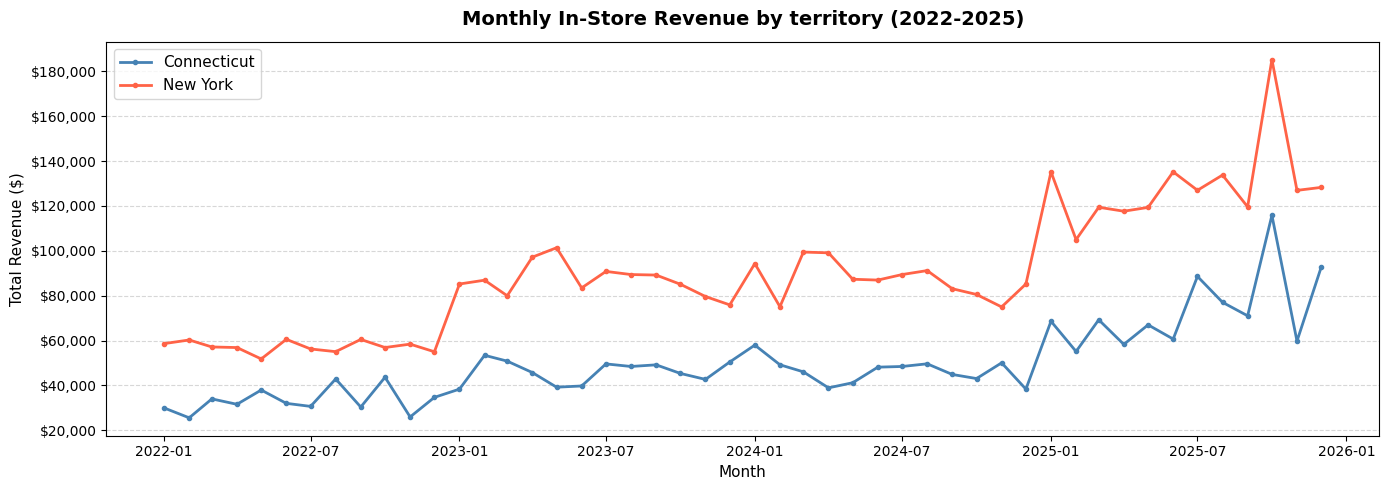

In [10]:
# Numeric monthly values for charting
ct_monthly_num = ct_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()
ny_monthly_num = ny_sales.groupby('YearMonth')['Sale Amount'].sum().reset_index()

# Convert period to datettime for plotting
ct_monthly_num['Month_dt'] = ct_monthly_num['YearMonth'].dt.to_timestamp()
ny_monthly_num['Month_dt'] = ny_monthly_num['YearMonth'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ct_monthly_num['Month_dt'], ct_monthly_num['Sale Amount'],
        label='Connecticut', color='steelblue', linewidth=2, marker='o', markersize=3)
ax.plot(ny_monthly_num['Month_dt'], ny_monthly_num['Sale Amount'], 
        label='New York', color='tomato', linewidth=2, marker='o', markersize=3)
ax.set_title('Monthly In-Store Revenue by territory (2022-2025)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Revenue ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
### Question 3: Store Peformance Ranking

**How would you rank the sales performance of each store in each territory?**

**Which are the top-performing stores?**

In [11]:
# Connecticut store rankings
ct_rank = ct_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
ct_rank = ct_rank.merge(store_detail[['Store ID', 'Store Location']], on='Store ID')
ct_rank = ct_rank.sort_values('Sale Amount', ascending=False).reset_index(drop=True)
ct_rank.index += 1

ct_rank_display = ct_rank.copy()
ct_rank_display['Sale Amount'] = ct_rank_display['Sale Amount'].map('${:,.2f}'.format)
print("Connecticut - Store Performance Ranking")
print("=" * 45)
print(ct_rank_display[['Store Location', 'Store ID', 'Sale Amount']].to_string())

# New York store rankings
ny_rank = ny_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
ny_rank = ny_rank.merge(store_detail[['Store ID', 'Store Location']], on='Store ID')
ny_rank = ny_rank.sort_values('Sale Amount', ascending=False).reset_index(drop=True)
ny_rank.index += 1

ny_rank_display = ny_rank.copy()
ny_rank_display['Sale Amount'] = ny_rank_display['Sale Amount'].map('${:,.2f}'.format)
print("\nNew York - Store Performance Ranking")
print("=" * 45)
print(ny_rank_display[['Store Location', 'Store ID', 'Sale Amount']].to_string())

Connecticut - Store Performance Ranking
      Store Location  Store ID  Sale Amount
1         New London       870  $331,116.76
2         Bridgeport       865  $322,100.07
3           Hartford       867  $309,592.06
4          Waterbury       872  $295,651.17
5          New Haven       869  $286,779.43
6  Litchfield County       868  $286,217.15
7             Darien       866  $283,455.62
8       Old Saybrook       871  $277,310.18

New York - Store Performance Ranking
   Store Location  Store ID  Sale Amount
1        New York       850  $621,565.02
2       Rochester       847  $607,148.21
3     Poestenkill       846  $334,175.88
4         Buffalo       841  $314,979.99
5          Elmira       842  $313,971.65
6          Ithaca       843  $313,920.05
7     Plattsburgh       845  $311,520.52
8          Albany       840  $310,389.02
9        Syracuse       848  $306,998.14
10       Brooklyn       849  $304,732.76
11         Oswego       844  $302,862.71
12         Queens       851  $288,

#### Chart 2 - Store Revenue Comparison (Bar Chart)

A horizontal bar chart works well here because we are comparing discrete stores. Sorting by revenue makes the ranking immediately clear.

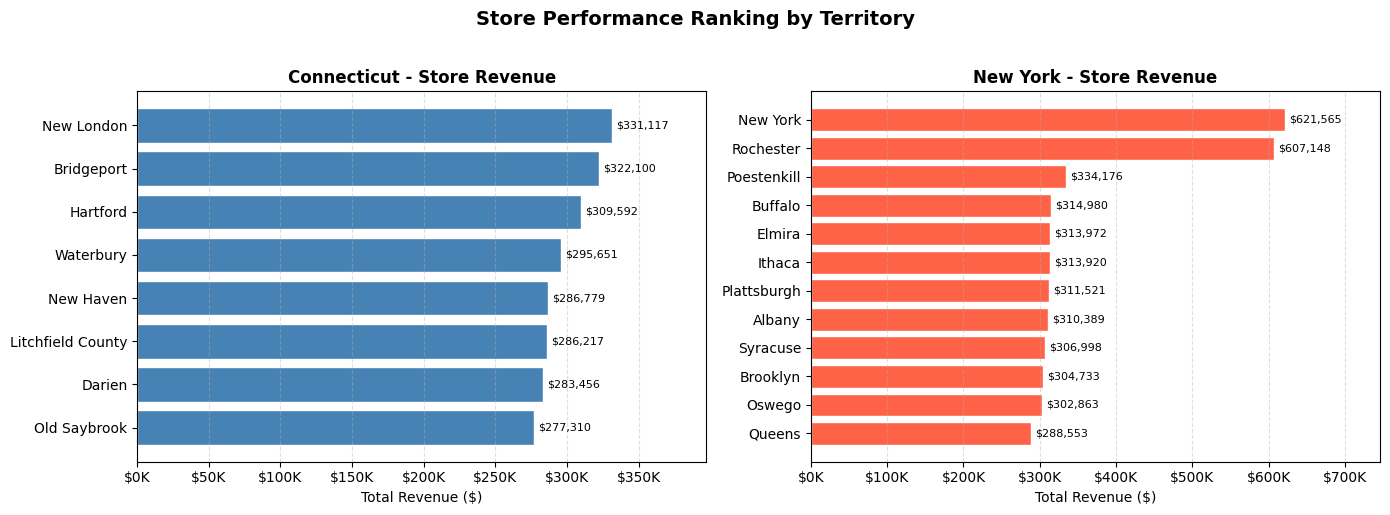

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Connecticut
ct_plot = ct_rank.sort_values('Sale Amount', ascending=True)
bars1 = ax1.barh(ct_plot['Store Location'], ct_plot['Sale Amount'],
                 color='steelblue', edgecolor='white')
ax1.set_title('Connecticut - Store Revenue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Revenue ($)', fontsize=10)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax1.bar_label(bars1, fmt=lambda x: f'${x:,.0f}', padding=3, fontsize=8)
ax1.set_xlim(0, ct_rank['Sale Amount'].max() * 1.2)
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# New York
ny_plot = ny_rank.sort_values('Sale Amount', ascending=True)
bars2 = ax2.barh(ny_plot['Store Location'], ny_plot['Sale Amount'],
                 color='tomato', edgecolor='white')
ax2.set_title('New York - Store Revenue', fontsize=12, fontweight='bold')
ax2.set_xlabel('Total Revenue ($)', fontsize=10)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.bar_label(bars2, fmt=lambda x: f'${x:,.0f}', padding=3, fontsize=8)
ax2.set_xlim(0, ny_rank['Sale Amount'].max() * 1.2)
ax2.grid(axis='x', linestyle='--', alpha=0.4)

fig.suptitle('Store Performance Ranking by Territory',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### Question 4: Top Customers by Territory

**Comparing the customer ID from the list with the rewards ID from the sales data, who were the top customers in each territory?**

The `RewardsID` column in StoreSales links to `cust_id` in customer_list.
Transactions without a RewardsID are anonymous (non-member) purchases.

In [13]:
# Connecticut's top customers
ct_rewards = ct_sales.dropna(subset=['RewardsID']).copy()
ct_rewards['RewardsID'] = ct_rewards['RewardsID'].astype(int)
ct_top = ct_rewards.groupby('RewardsID')['Sale Amount'].sum().reset_index()
ct_top = ct_top.merge(customer_list[['cust_id', 'name']],
                      left_on='RewardsID', right_on='cust_id', how='left')
ct_top = ct_top.sort_values('Sale Amount', ascending=False).head(10).reset_index(drop=True)
ct_top.index += 1
ct_top_display = ct_top.copy()
ct_top_display['Sale Amount'] = ct_top_display['Sale Amount'].map('${:,.2f}'.format)
print("Connecticut - Top 10 Rewards Customers (by Total Spend)")
print("=" * 50)
print(ct_top_display[['name', 'RewardsID', 'Sale Amount',]].to_string())

# New York's top customers
ny_rewards = ny_sales.dropna(subset=['RewardsID']).copy()
ny_rewards['RewardsID'] = ny_rewards['RewardsID'].astype(int)
ny_top = ny_rewards.groupby('RewardsID')['Sale Amount'].sum().reset_index()
ny_top = ny_top.merge(customer_list[['cust_id', 'name']],
                      left_on='RewardsID', right_on='cust_id', how='left')
ny_top = ny_top.sort_values('Sale Amount', ascending=False).head(10).reset_index(drop=True)
ny_top.index += 1
ny_top_display = ny_top.copy()
ny_top_display['Sale Amount'] = ny_top_display['Sale Amount'].map('${:,.2f}'.format)
print("\nNew York - Top 10 Rewards Customers (by Total Spend)")
print("=" * 50)
print(ny_top_display[['name', 'RewardsID', 'Sale Amount',]].to_string())

Connecticut - Top 10 Rewards Customers (by Total Spend)
               name  RewardsID Sale Amount
1          Marie S.         18   $4,388.87
2          Jon Snow         21   $3,676.21
3        Fox Mulder        322   $3,569.60
4        Pugsley A.        365   $3,009.29
5          Helen M.        104   $2,886.72
6            Buford        519   $2,766.60
7          Jin Kwon        340   $2,691.89
8   Jean-Luc Picard        286   $2,624.61
9        Miss Piggy        197   $2,496.08
10   Cedric Daniels        471   $2,376.77

New York - Top 10 Rewards Customers (by Total Spend)
             name  RewardsID Sale Amount
1   Julian Bashir        300   $6,039.32
2    Jason Morgan        129   $3,918.72
3    Mellie Grant        188   $3,805.61
4     Peggy Olson        483   $3,504.20
5           Gonzo        199   $3,441.19
6       Britta P.         67   $3,426.57
7         Waldorf        204   $3,348.62
8      John Locke        335   $3,280.21
9       Marion C.        152   $3,213.63
10     

---
### Question 5: Transactions and Revenue by Product Category

**What is the number of transactions per month by product category in each territory?**

**What is the total sales revenue per month by category?**

**What might this tell you about the most popular products, and where could there be opportunity for growth?**

In [14]:
# Merge sales with products and categories
sales_products = store_sales.merge(
    products[['Prod Num', 'CategoryID', 'SubcategoryID']], on='Prod Num', how='left'
)
sales_products = sales_products.merge(
    product_cats[['CategoryID', 'Category']], on='CategoryID', how='left'
)

# filter
ct_sp = sales_products[sales_products['Store ID'].isin(ct_ids)]
ny_sp = sales_products[sales_products['Store ID'].isin(ny_ids)]

# Aggregate by category
ct_cat = ct_sp.groupby('Category').agg(
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).sort_values('Total_Revenue', ascending=False).reset_index()

ny_cat = ny_sp.groupby('Category').agg(
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).sort_values('Total_Revenue', ascending=False).reset_index()

ct_cat_display = ct_cat.copy()
ct_cat_display['Total_Revenue'] = ct_cat_display['Total_Revenue'].map('${:,.2f}'.format)
print("Connecticut - Revenue & Transactions by Product Category")
print("=" * 60)
print(ct_cat_display.to_string(index=False))

ny_cat_display = ny_cat.copy()
ny_cat_display['Total_Revenue'] = ny_cat_display['Total_Revenue'].map('${:,.2f}'.format)
print("\nNew York - Revenue & Transactions by Product Category")
print("=" * 60)
print(ny_cat_display.to_string(index=False))

Connecticut - Revenue & Transactions by Product Category
                Category  Transactions  Total_Revenue
Technology & Accessories         25655 $11,955,289.08
               Textbooks         25971  $4,493,254.81
            Art Supplies         31240  $1,001,627.44
 Apparel and Merchandise         27168    $857,295.12
 Stationery and Supplies         40909    $407,380.16
         Books (General)          5588    $162,371.20

New York - Revenue & Transactions by Product Category
                Category  Transactions  Total_Revenue
Technology & Accessories         45164 $21,498,107.75
               Textbooks         48664  $8,435,652.94
            Art Supplies         55572  $1,747,094.69
 Apparel and Merchandise         49032  $1,585,641.12
 Stationery and Supplies         72039    $724,130.99
         Books (General)          9732    $279,677.12


#### Chart 3 - Revenue by Product Category (Bar Chart)

A bar chart lets us compare category performance across both territories. Notice how the same ranking order holds in both. Tech dominates, Stationery has tons of transactions but very low revenue.

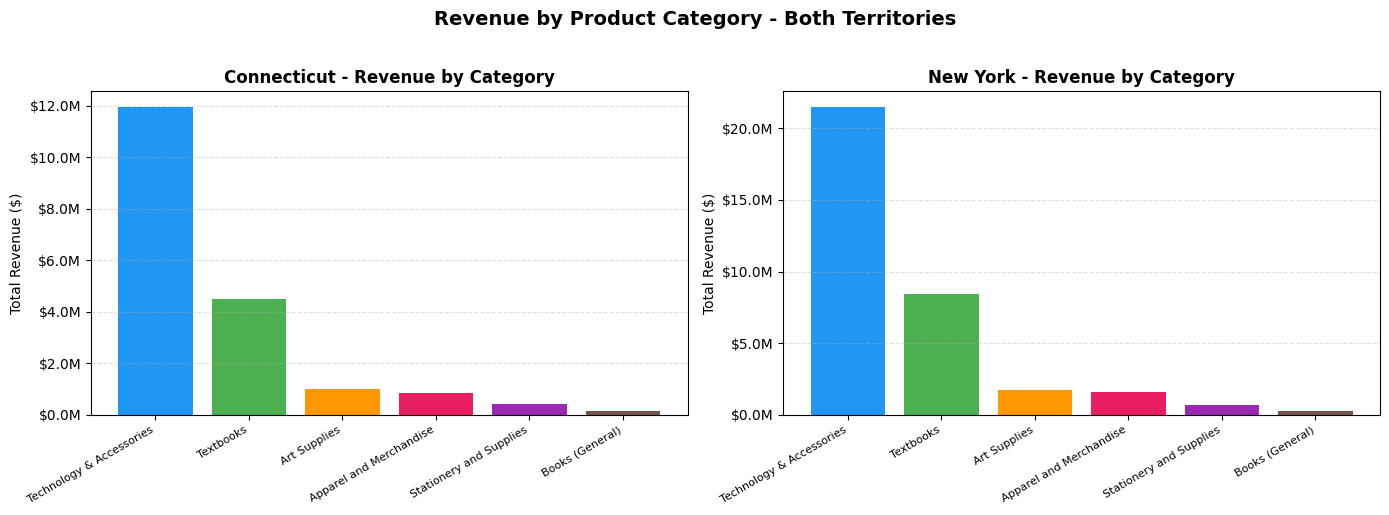

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#795548']

ax1.bar(ct_cat['Category'], ct_cat['Total_Revenue'], color=colors)
ax1.set_title('Connecticut - Revenue by Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Revenue ($)', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax1.tick_params(axis='x', labelrotation=30)
for label in ax1.get_xticklabels():
    label.set_ha('right')
    label.set_fontsize(8)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2.bar(ny_cat['Category'], ny_cat['Total_Revenue'], color=colors)
ax2.set_title('New York - Revenue by Category', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Revenue ($)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax2.tick_params(axis='x', labelrotation=30)
for label in ax2.get_xticklabels():
    label.set_ha('right')
    label.set_fontsize(8)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Revenue by Product Category - Both Territories',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

--- 
### Question 6: Marketing Recommendation for Next Quarter

#### Key Findings Summary

1. **Revenue Gap:** New York generates 4.3M dollars vs Connecticut's 2.4M dollars - partly explained by more stores (12 vs 8), but NY also leads on per-store average.
2. **Top Stores:** In CT, **New London** and **Bridgeport** lead. In NY, **New York City** and **Rochester** are dominant - both far ahead of the next store.
3. **Underperformers:** CT's **Old Saybrook** trails the territory leader by 54K. In NY, **Queens** significantly underperforms its NYC-area peers despite sharing the same market.
4. **Categories:** **Technology & Accessories** drives the most revenue by far in both territories. **Stationary & Supplies** has the highest transaction count but the lowest revenue per sale - high volumn, low value. **Books (General)** is the weakest category on both measures.
5. **Rewards Members:** Julian Bashir leads NY at $6,049 total spend. Marie S. leads CT at 4,389. These high-value members are prime targets for loyalty campaigns.

---

#### Recommendation

**Focus: Lift CT underperformers + activate NY Queens with Tech promotions**

Connecticut's stores are closely clustered in revenue - Old Saybrook and Darien are only $54K behind the leader, which means a targeted push could move them up quickly. A **back-to-school tech promotion** (laptops, tablets, accessories) at those stores aligns with the data: Technology is the #1 revenue driver and where dollars are spent.

In New York, the **Queen's Store** is underperforming relative to Brooklyn and the NYC flagship despite being in the same metro area. A **localized marketing campaign** with student tech bundles and textbook season promotions, that could close the gap.

Across both territories, a **Rewards Member re-engagement campaign** targeting the top spenders and lapsed members is a low-cost, high-return opportunity since rewards customers already demonstrate strong purchase intent.